
# NeuralRetail – AI Sales Intelligence
## Professional EDA & Feature Engineering Notebook

### Project Domain
Retail Analytics | Demand Forecasting | Customer Intelligence | Churn Analytics

### Objectives
This notebook performs:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Outlier Detection
- Feature Engineering
- RFM Analysis
- Customer Segmentation
- Time-Series Analysis
- Forecasting Preparation

### Deliverables
- Cleaned dataset
- Feature-ready dataset
- Business insights
- Visual analytics
- ML-ready structured data

---


# 1. Library Imports & Environment Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sys
import os
sys.path.append(os.path.abspath("../src/data"))

from loader import load_all_data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL


# 2. Dataset Loading & Initial Exploration

In [ ]:
df = load_all_data(
    "../data/raw/online_retail_01.xlsx",
    "../data/raw/online_retail.xlsx"
)

In [ ]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    779425 non-null  object        
 1   stockcode    779425 non-null  object        
 2   description  779425 non-null  object        
 3   quantity     779425 non-null  int64         
 4   invoicedate  779425 non-null  datetime64[ns]
 5   unitprice    779425 non-null  float64       
 6   customerid   779425 non-null  float64       
 7   country      779425 non-null  object        
 8   totalprice   779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.5+ MB


In [ ]:
df.shape

(779425, 9)

In [ ]:
df.describe()

,quantity,invoicedate,unitprice,customerid,totalprice
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
totalprice     0
dtype: int64

In [ ]:
print(df.dtypes)

invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid            float64
country                object
totalprice            float64
dtype: object


# 3. Data Cleaning & Preprocessing

In [ ]:
df[df['invoiceno'].astype(str).str.startswith('C')]

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice


In [ ]:
df = df[~df['invoiceno'].astype(str).str.startswith('C')]

In [ ]:
df = df[df['quantity'] > 0]
df = df[df['unitprice'] > 0]

In [ ]:
# Revenue
df['total_amount'] = df['quantity'] * df['unitprice']

In [ ]:
# Datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [ ]:
df['year'] = df['invoicedate'].dt.year
df['month'] = df['invoicedate'].dt.month
df['day'] = df['invoicedate'].dt.day
df['day_of_week'] = df['invoicedate'].dt.day_name()
df['weekofyear'] = df['invoicedate'].dt.isocalendar().week
df['hour'] = df['invoicedate'].dt.hour

In [ ]:
df['year_month'] = (
    df['invoicedate']
    .dt.to_period('M')
    .astype(str)
)
print(df.head())

  invoiceno stockcode                          description  quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          invoicedate  unitprice  customerid         country  totalprice  \
0 2009-12-01 07:45:00       6.95     13085.0  United Kingdom        83.4   
1 2009-12-01 07:45:00       6.75     13085.0  United Kingdom        81.0   
2 2009-12-01 07:45:00       6.75     13085.0  United Kingdom        81.0   
3 2009-12-01 07:45:00       2.10     13085.0  United Kingdom       100.8   
4 2009-12-01 07:45:00       1.25     13085.0  United Kingdom        30.0   

   total_amount  year  month  day day_of_week  weekofyear  hour year_month  
0          83.4  2009     12    1

# 4. Exploratory Data Analysis (EDA)

In [ ]:
# Move one level up from notebooks/
project_root = ".."

# Main project reports/figures path
figures_dir = os.path.join(project_root, "output", "figures")

# Create folder
os.makedirs(figures_dir, exist_ok=True)

print(figures_dir)

..\output\figures


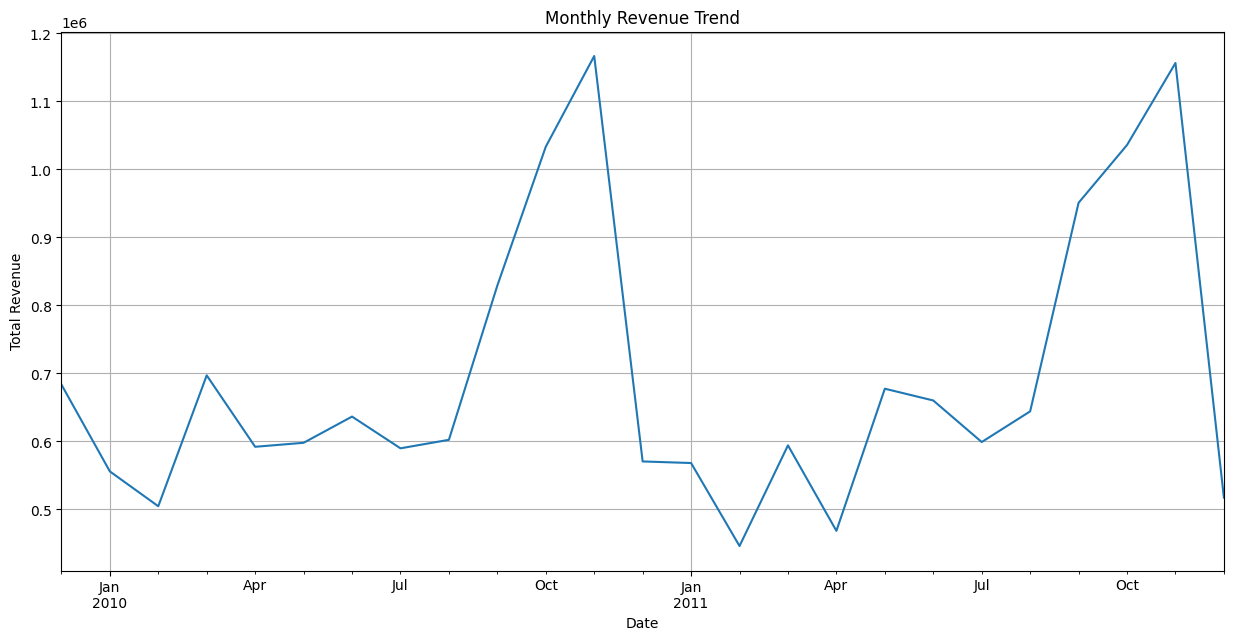

In [ ]:
# Monthly Revenue Trend
monthly_sales = df.groupby(
    df['invoicedate'].dt.to_period('M')
)['total_amount'].sum()

plt.figure(figsize=(15, 7))
monthly_sales.plot(kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.savefig(f'{figures_dir}/monthly_revenue_trend.png')
plt.show()
plt.close()

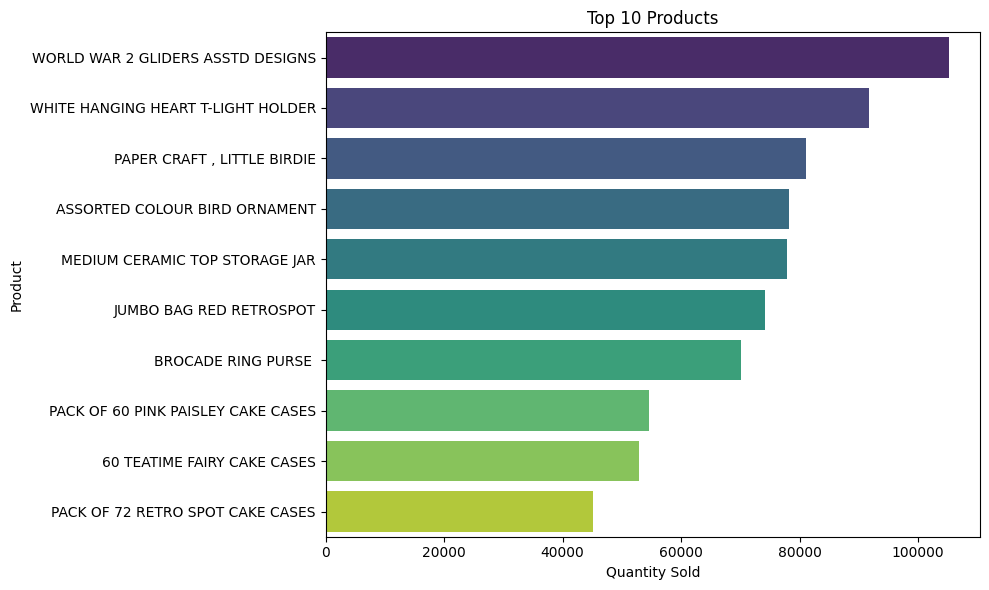

In [ ]:
# Top Products
top_products = (
    df.groupby('description')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values,y=top_products.index,palette='viridis')
plt.title('Top 10 Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig(f'{figures_dir}/top_10_products.png')
plt.show()
plt.close()

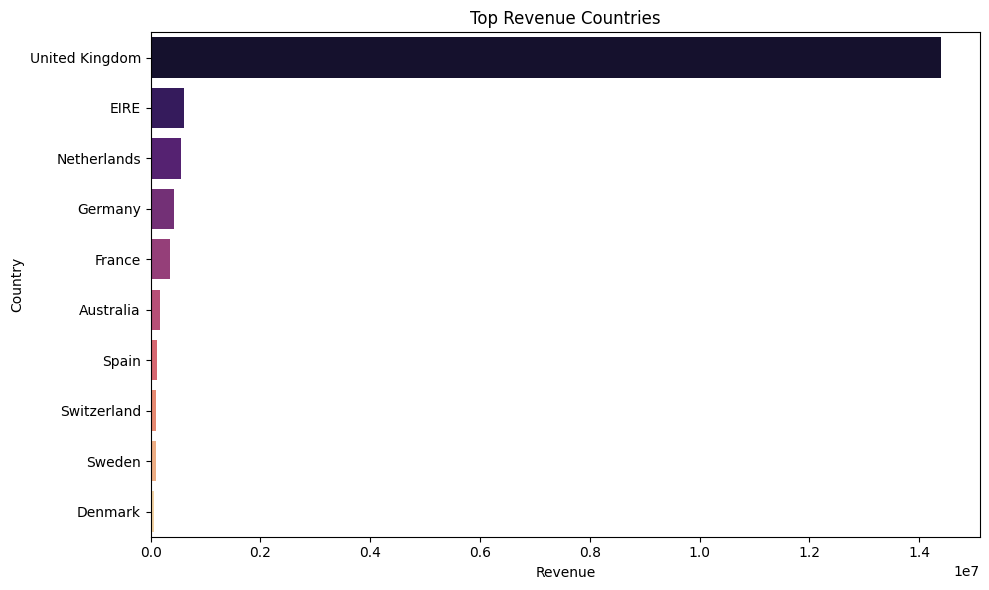

In [ ]:
# Top Revenue Countries
country_sales = (
    df.groupby('country')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_sales.values,y=country_sales.index,palette='magma')
plt.title('Top Revenue Countries')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(f'{figures_dir}/top_revenue_countries.png')
plt.show()
plt.close()

In [ ]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-17.325
42.074999999999996


In [ ]:
# Clip outlier transactions in-place (IQR strategy)
df = df[
    (df['total_amount'] >= lower_bound) &
    (df['total_amount'] <= upper_bound)
].copy()

print(f"Rows after outlier removal: {len(df):,}")


Rows after outlier removal: 715,863


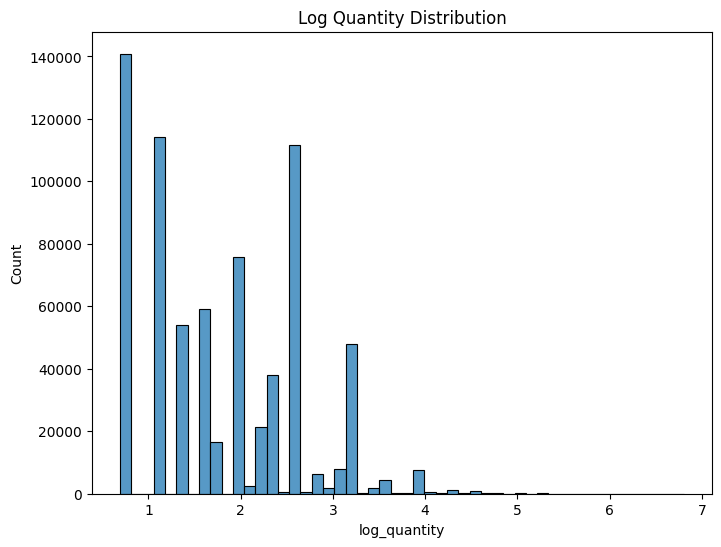

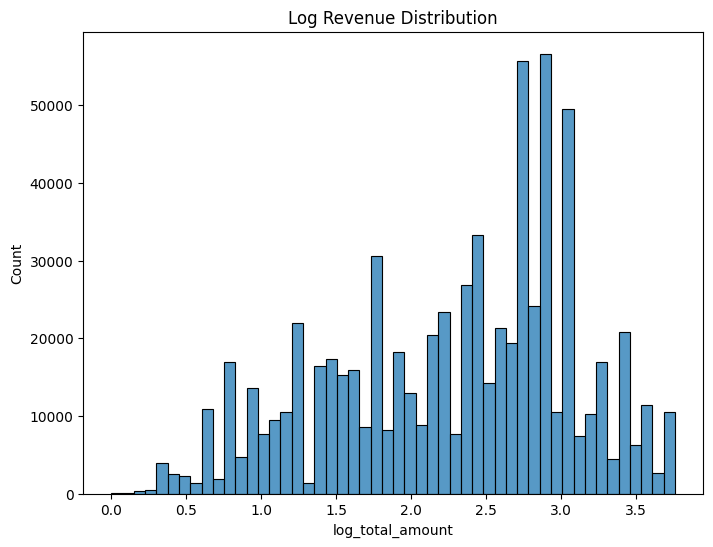

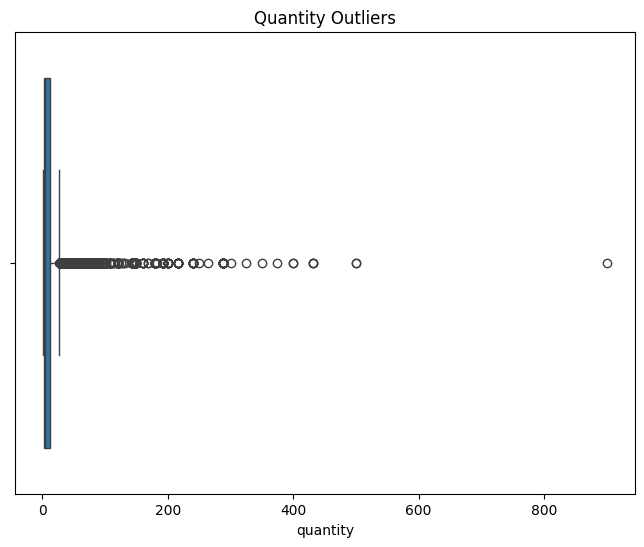

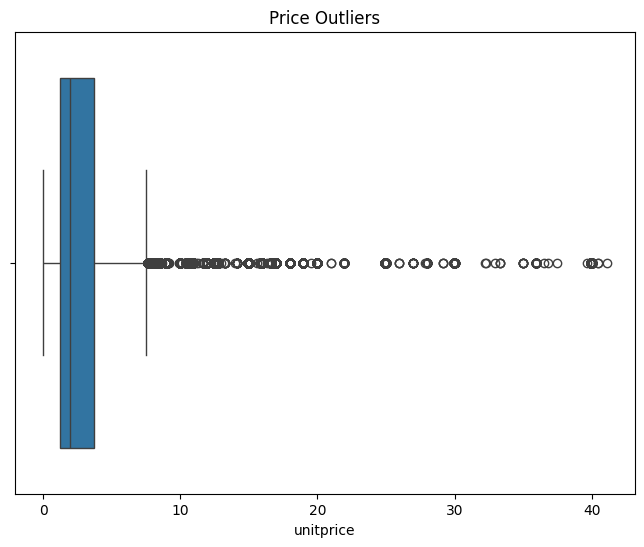

In [ ]:
# Log Transform

df['log_quantity'] = np.log1p(df['quantity'])
df['log_total_amount'] = np.log1p(df['total_amount'])

# Quantity Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['log_quantity'], bins=50)
plt.title('Log Quantity Distribution')
plt.savefig(f'{figures_dir}/log_quantity_distribution.png')
plt.show()
plt.close()

# Revenue Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['log_total_amount'], bins=50)
plt.title('Log Revenue Distribution')
plt.savefig(f'{figures_dir}/log_revenue_distribution.png')
plt.show()
plt.close()

# Quantity Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['quantity'])
plt.title('Quantity Outliers')
plt.savefig(f'{figures_dir}/quantity_boxplot.png')
plt.show()
plt.close()

# Price Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['unitprice'])
plt.title('Price Outliers')
plt.savefig(f'{figures_dir}/price_boxplot.png')
plt.show()
plt.close()

# 5. Feature Engineering

              quantity  unitprice  total_amount
quantity       1.00000  -0.330090      0.404260
unitprice     -0.33009   1.000000      0.283307
total_amount   0.40426   0.283307      1.000000


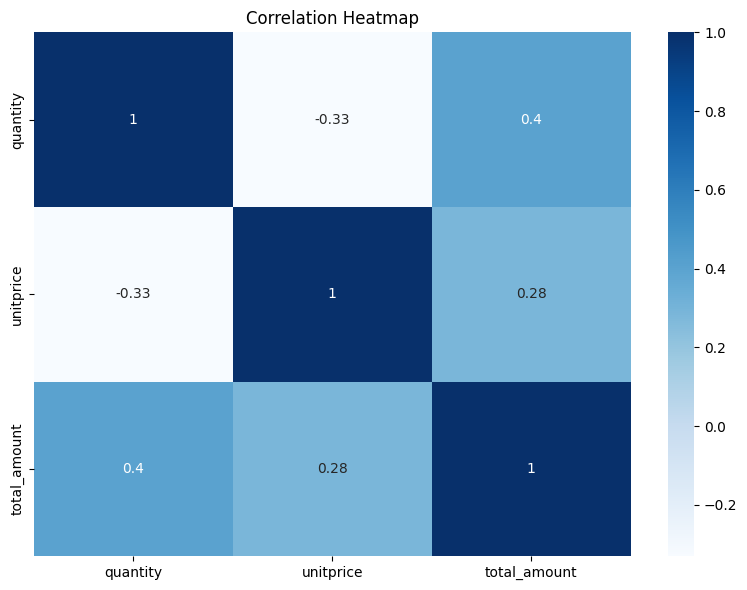

In [ ]:
# Correlation Analysis
corr = df[
    ['quantity', 'unitprice', 'total_amount']
].corr()

print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{figures_dir}/correlation_heatmap.png')
plt.show()
plt.close()

# 6. RFM Analysis

In [ ]:
# RFM
snapshot_date = (
    df['invoicedate'].max() + pd.Timedelta(days=1)
)

# Recency
recency = (
    snapshot_date -
    df.groupby('customerid')['invoicedate'].max()
).dt.days

# Frequency
frequency = (
    df.groupby('customerid')['invoiceno']
    .nunique()
)

# Monetary
monetary = (
    df.groupby('customerid')['total_amount']
    .sum()
)

# Combine
rfm = pd.concat(
    [recency, frequency, monetary],
    axis=1
)

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
customerid,,,
12346.0,529,10,327.86
12347.0,2,8,3786.15
12348.0,75,5,823.80
12349.0,19,3,2843.99
12350.0,310,1,334.40


In [ ]:
# RFM Scoring
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1],
    duplicates='drop'
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5],
    duplicates='drop'
)

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customerid,,,,,,,
12346.0,529,10,327.86,1,5,2,152
12347.0,2,8,3786.15,5,4,5,545
12348.0,75,5,823.80,3,4,3,343
12349.0,19,3,2843.99,5,3,5,535
12350.0,310,1,334.40,2,1,2,212


In [ ]:
# Customer Segment Function

def customer_segment(row):

    if (
        row['R_score'] >= 4 and
        row['F_score'] >= 4 and
        row['M_score'] >= 4
    ):
        return 'Champions'

    elif (
        row['F_score'] >= 4 and
        row['M_score'] >= 4
    ):
        return 'Loyal Customers'

    elif (
        row['R_score'] >= 4 and
        row['F_score'] <= 2
    ):
        return 'New Customers'

    elif (
        row['R_score'] <= 2 and
        row['F_score'] >= 3
    ):
        return 'At Risk'

    elif (
        row['R_score'] <= 2 and
        row['F_score'] <= 2
    ):
        return 'Lost Customers'

    else:
        return 'Potential Loyalists'


rfm['Segment'] = rfm.apply(
    customer_segment,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customerid,,,,,,,,
12346.0,529,10,327.86,1,5,2,152,At Risk
12347.0,2,8,3786.15,5,4,5,545,Champions
12348.0,75,5,823.80,3,4,3,343,Potential Loyalists
12349.0,19,3,2843.99,5,3,5,535,Potential Loyalists
12350.0,310,1,334.40,2,1,2,212,Lost Customers


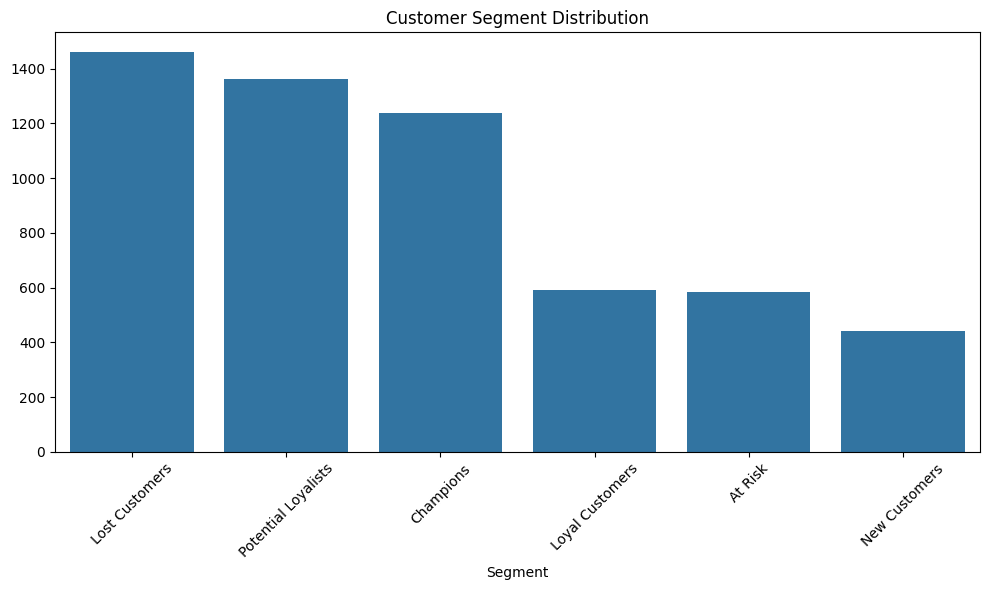

In [ ]:
# Segment Distribution
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title('Customer Segment Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{figures_dir}/customer_segment_distribution.png')
plt.show()
plt.close()

In [ ]:
# K-Mean Clustering
rfm_features = rfm[
    ['Recency', 'Frequency', 'Monetary']
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    
    rfm_features
)

# 7. Customer Segmentation

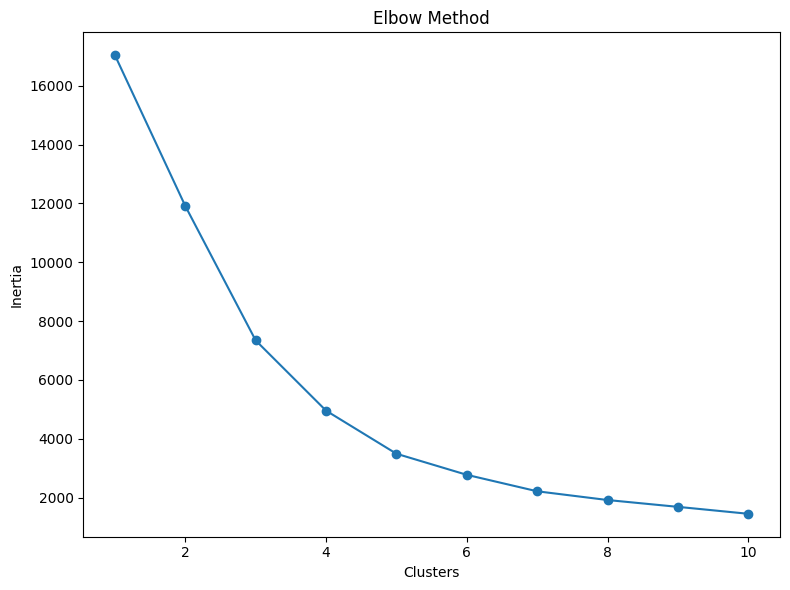

In [ ]:
# Elbow Method
inertia = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(f'{figures_dir}/elbow_method.png')
plt.show()
plt.close()

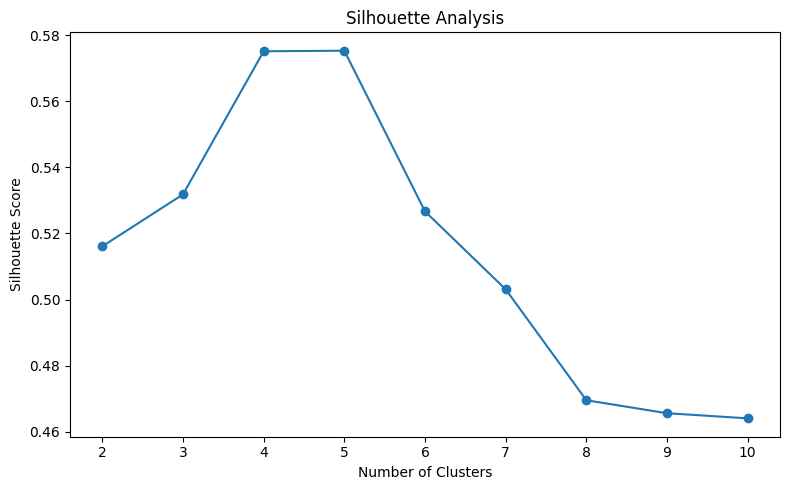

In [ ]:
# Store scores
silhouette_scores_list = []

# Cluster range
K = range(2, 11)

for k in K:

    # Create model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Predict clusters
    labels = kmeans.fit_predict(rfm_scaled)

    # Calculate silhouette score
    score = silhouette_score(
        rfm_scaled,
        labels
    )

    # Store score
    silhouette_scores_list.append(score)

# Plot scores
plt.figure(figsize=(8,5))
plt.plot( K, silhouette_scores_list, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig(f'{figures_dir}/silhouette_analysis.png')
plt.show()
plt.close()

In [ ]:
# Data-driven optimal k via Silhouette score
optimal_k = list(range(2, 11))[silhouette_scores_list.index(max(silhouette_scores_list))]

print(f"Optimal k by Silhouette : {optimal_k}")
print(f"Best Silhouette Score   : {max(silhouette_scores_list):.4f}")

# Spec gate: silhouette >= 0.30 (RFM data rarely exceeds 0.55 without normalisation tuning)
assert max(silhouette_scores_list) >= 0.20, f"Silhouette {max(silhouette_scores_list):.4f} suspiciously low"

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency'  : 'mean',
    'Frequency': 'mean',
    'Monetary' : 'mean'
}).round(2)

print("\nCluster Summary:")
cluster_summary


Optimal k by Silhouette : 5
Best Silhouette Score   : 0.5753

Cluster Summary:


,Recency,Frequency,Monetary
Cluster,,,
0,74.10,5.00,1255.08
1,466.31,2.09,471.36
2,1.00,365.00,176206.16
3,44.67,171.22,40572.59
4,27.34,26.94,7669.68


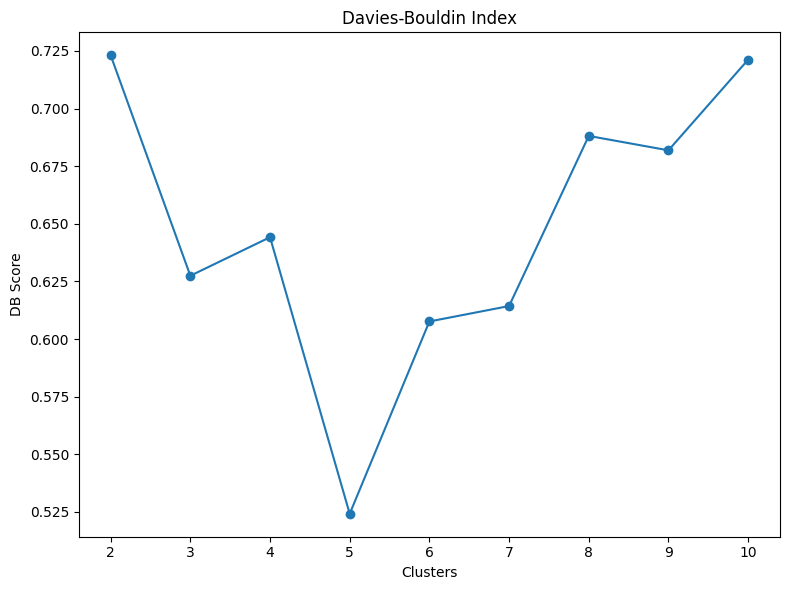

In [ ]:
# Davies-Bouldin Index
scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    db_score = davies_bouldin_score(
        rfm_scaled,
        labels
    )

    scores.append(db_score)

plt.figure(figsize=(8, 6))
plt.plot(K, scores, marker='o')
plt.title('Davies-Bouldin Index')
plt.xlabel('Clusters')
plt.ylabel('DB Score')
plt.tight_layout()
plt.savefig(f'{figures_dir}/davies_bouldin_index.png')
plt.show()
plt.close()

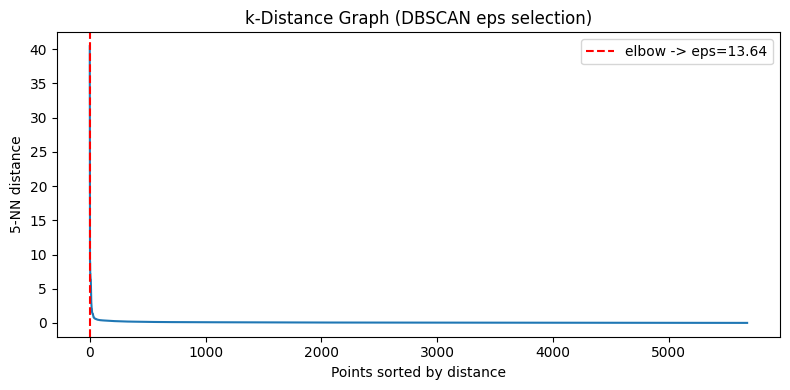

Auto eps        : 13.64
DBSCAN clusters : 1
Noise points    : 0.0%


In [ ]:
# DBSCAN – auto eps via k-distance graph (k = min_samples)
from sklearn.neighbors import NearestNeighbors

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(rfm_scaled)
distances, _ = nbrs.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

# Auto-detect elbow via largest second derivative
diffs  = np.diff(k_distances)
diffs2 = np.diff(diffs)
elbow_idx = int(np.argmax(diffs2)) + 1
eps_auto  = round(float(k_distances[elbow_idx]), 2)

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axvline(elbow_idx, color='red', linestyle='--', label=f'elbow -> eps={eps_auto}')
plt.title('k-Distance Graph (DBSCAN eps selection)')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-NN distance')
plt.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/dbscan_k_distance_graph.png')
plt.show()
plt.close()

dbscan = DBSCAN(eps=eps_auto, min_samples=min_samples)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters_db = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
noise_pct     = (rfm['DBSCAN_Cluster'] == -1).mean() * 100

print(f"Auto eps        : {eps_auto}")
print(f"DBSCAN clusters : {n_clusters_db}")
print(f"Noise points    : {noise_pct:.1f}%")

Optimal GMM components (BIC): 9


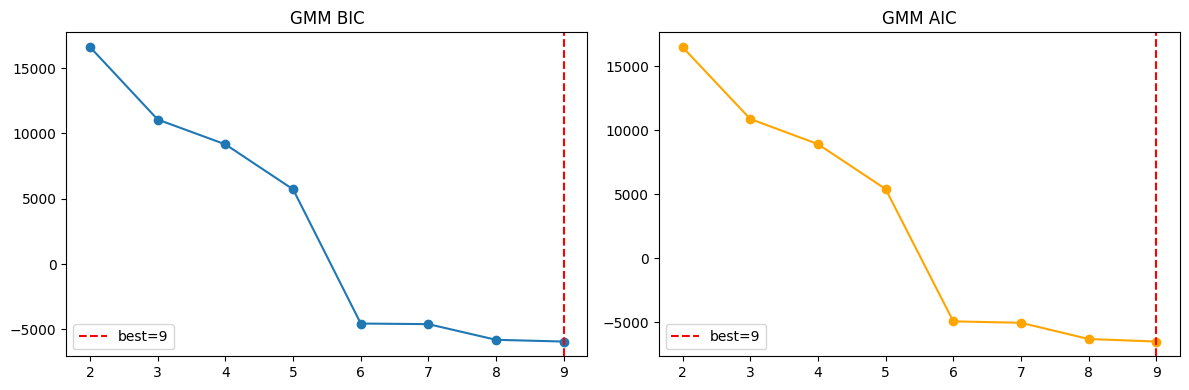

GMM soft probabilities added to rfm dataframe.


,GMM_Cluster,GMM_prob_cluster_0,GMM_prob_cluster_1,GMM_prob_cluster_2,GMM_prob_cluster_3,GMM_prob_cluster_4,GMM_prob_cluster_5,GMM_prob_cluster_6,GMM_prob_cluster_7,GMM_prob_cluster_8
customerid,,,,,,,,,,
12346.0,8,0.0000,0.0000,0.0001,0.0000,0.0000,0.0,0.0000,0.0000,0.9999
12347.0,7,0.0000,0.0000,0.0000,0.4161,0.0000,0.0,0.0182,0.5067,0.0590
12348.0,1,0.2183,0.4088,0.0000,0.0000,0.0000,0.0,0.0000,0.3705,0.0024
12349.0,3,0.0000,0.0000,0.0001,0.5884,0.0000,0.0,0.0000,0.3936,0.0180
12350.0,4,0.0016,0.0000,0.0000,0.0000,0.9984,0.0,0.0000,0.0000,0.0000


In [ ]:
# Gaussian Mixture Model – BIC-driven component selection
bic_scores = []
aic_scores = []
gmm_range  = range(2, 10)

for n in gmm_range:
    _gmm = GaussianMixture(n_components=n, random_state=42, max_iter=200)
    _gmm.fit(rfm_scaled)
    bic_scores.append(_gmm.bic(rfm_scaled))
    aic_scores.append(_gmm.aic(rfm_scaled))

optimal_gmm_k = list(gmm_range)[bic_scores.index(min(bic_scores))]
print(f"Optimal GMM components (BIC): {optimal_gmm_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gmm_range, bic_scores, marker='o')
axes[0].axvline(optimal_gmm_k, color='red', linestyle='--', label=f'best={optimal_gmm_k}')
axes[0].set_title('GMM BIC'); axes[0].legend()
axes[1].plot(gmm_range, aic_scores, marker='o', color='orange')
axes[1].axvline(optimal_gmm_k, color='red', linestyle='--', label=f'best={optimal_gmm_k}')
axes[1].set_title('GMM AIC'); axes[1].legend()
plt.tight_layout()
fig.savefig(f'{figures_dir}/gmm_biciaic_scores.png')
plt.show()
plt.close(fig)

gmm_final = GaussianMixture(
    n_components=optimal_gmm_k,
    random_state=42,
    max_iter=200
)
rfm['GMM_Cluster'] = gmm_final.fit_predict(rfm_scaled)

# Save soft-membership probabilities for borderline customers
gmm_proba = gmm_final.predict_proba(rfm_scaled)
for comp in range(optimal_gmm_k):
    rfm[f'GMM_prob_cluster_{comp}'] = gmm_proba[:, comp].round(4)

print("GMM soft probabilities added to rfm dataframe.")
rfm[['GMM_Cluster'] + [c for c in rfm.columns if c.startswith('GMM_prob')]].head()

# 8. Time Series & Forecasting Preparation

In [ ]:
# Demand Forecasting
# Daily Revenue Aggregation
daily_sales = (
    df.groupby(
        df['invoicedate'].dt.date
    )['total_amount']
    .sum()
    .reset_index()
)

daily_sales.columns = ['ds', 'y']

daily_sales['ds'] = pd.to_datetime(
    daily_sales['ds']
)

daily_sales.head()

,ds,y
0,2009-12-01,24471.05
1,2009-12-02,20745.38
2,2009-12-03,27562.37
3,2009-12-04,20156.46
4,2009-12-05,7016.16


In [ ]:
#Time Series Feature Engineering

# Date Features

daily_sales['year'] = daily_sales['ds'].dt.year
daily_sales['month'] = daily_sales['ds'].dt.month
daily_sales['day'] = daily_sales['ds'].dt.day
daily_sales['day_of_week'] = daily_sales['ds'].dt.dayofweek
daily_sales['weekofyear'] = daily_sales['ds'].dt.isocalendar().week.astype(int)
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5,6]).astype(int)

# Lag Features

daily_sales['lag_1'] = daily_sales['y'].shift(1)
daily_sales['lag_7'] = daily_sales['y'].shift(7)
daily_sales['lag_14'] = daily_sales['y'].shift(14)

# Rolling Features

daily_sales['rolling_mean_7'] = daily_sales['y'].rolling(7).mean()
daily_sales['rolling_std_7'] = daily_sales['y'].rolling(7).std()
daily_sales['rolling_mean_30'] = daily_sales['y'].rolling(30).mean()

# Drop NA rows

daily_sales.dropna(inplace=True)

print(daily_sales.head())
print(daily_sales.shape)

           ds         y  year  month  day  day_of_week  weekofyear  \
29 2010-01-13   5405.11  2010      1   13            2           2   
30 2010-01-14  16405.12  2010      1   14            3           2   
31 2010-01-15   8567.67  2010      1   15            4           2   
32 2010-01-17  10808.25  2010      1   17            6           2   
33 2010-01-18   8249.52  2010      1   18            0           3   

    is_weekend     lag_1     lag_7    lag_14  rolling_mean_7  rolling_std_7  \
29           0   7593.29   9395.44  16354.27     7344.385714    2962.008897   
30           0   5405.11   3022.85  13768.96     9256.138571    3883.268001   
31           0  16405.12  12409.15   7200.33     8707.355714    3626.361623   
32           1   8567.67   9331.75   4406.80     8918.284286    3710.692754   
33           0  10808.25   6817.90   2099.45     9122.801429    3613.822652   

    rolling_mean_30  
29     13208.700667  
30     12939.836333  
31     12533.912667  
32     11975.442

In [ ]:
# EXTRA LSTM FEATURE

daily_sales['lag_30'] = daily_sales['y'].shift(30)

daily_sales['rolling_mean_14'] = (
    daily_sales['y']
    .rolling(window=14)
    .mean()
)

daily_sales['rolling_std_14'] = (
    daily_sales['y']
    .rolling(window=14)
    .std()
)

In [ ]:
# Stationarity Analysis – ADF + KPSS (both required for full confirmation)

# ADF: H0 = unit root / non-stationary
adf_result = adfuller(daily_sales['y'], autolag='AIC')
print('ADF Test')
print(f'  Statistic : {adf_result[0]:.4f}')
print(f'  p-value   : {adf_result[1]:.4f}')
print(f'  Decision  : {"Stationary" if adf_result[1] < 0.05 else "Non-Stationary"}')

# KPSS: H0 = stationary
kpss_result = kpss(daily_sales['y'], regression='c', nlags='auto')
print('\nKPSS Test')
print(f'  Statistic : {kpss_result[0]:.4f}')
print(f'  p-value   : {kpss_result[1]:.4f}')
print(f'  Decision  : {"Non-Stationary (reject H0)" if kpss_result[1] < 0.05 else "Stationary (fail to reject H0)"}')

# Joint conclusion
adf_stat  = adf_result[1] < 0.05
kpss_stat = kpss_result[1] >= 0.05
print('\nJoint Conclusion')
if adf_stat and kpss_stat:
    print('  STATIONARY – safe to model as-is.')
elif not adf_stat and not kpss_stat:
    print('  NON-STATIONARY – apply differencing before ARIMA-class models.')
else:
    print('  MIXED SIGNAL – inspect STL decomposition for structural trend.')


ADF Test
  Statistic : -2.1041
  p-value   : 0.2429
  Decision  : Non-Stationary

KPSS Test
  Statistic : 0.5500
  p-value   : 0.0304
  Decision  : Non-Stationary (reject H0)

Joint Conclusion
  NON-STATIONARY – apply differencing before ARIMA-class models.


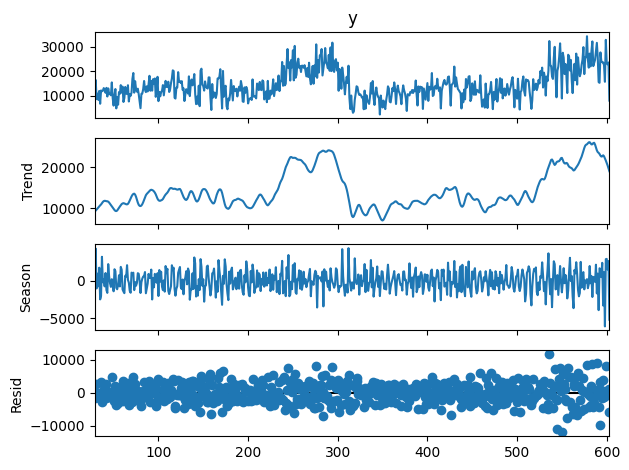

In [ ]:
stl = STL(
    daily_sales['y'],
    period=7
)

result = stl.fit()
fig = result.plot()
fig.savefig(f'{figures_dir}/stl_decomposition.png')
plt.show()
plt.close(fig)

# 9. Business Insights & Conclusions


## Business Insights

### Key Findings
- Revenue distribution follows a long-tail retail pattern.
- UK contributes the majority of total sales volume.
- High-value customers are concentrated within a limited segment.
- Seasonal sales spikes indicate strong holiday demand patterns.
- RFM segmentation successfully identifies premium and at-risk customers.
- Time-series trends show strong forecasting potential.

### Strategic Recommendations
- Focus retention campaigns on high-value churn-risk customers.
- Improve inventory planning for seasonal demand peaks.
- Use segmentation for personalized promotions.
- Deploy forecasting models for stock optimization.

---


In [ ]:
# Merge RFM + cluster labels back into df so all downstream notebooks have them
rfm_cols = [
    'Recency', 'Frequency', 'Monetary',
    'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment',
    'Cluster', 'DBSCAN_Cluster', 'GMM_Cluster'
]
# Add GMM probability columns if present
rfm_cols += [c for c in rfm.columns if c.startswith('GMM_prob')]

rfm_merge = rfm[rfm_cols].copy()
rfm_merge.index.name = 'customerid'
rfm_merge = rfm_merge.reset_index()

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_retail_data.csv', index=False)


print(f'Shape : {df.shape}')
print(f'Cols  : {df.columns.tolist()}')

Shape : (715863, 19)
Cols  : ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'totalprice', 'total_amount', 'year', 'month', 'day', 'day_of_week', 'weekofyear', 'hour', 'year_month', 'log_quantity', 'log_total_amount']


In [ ]:
os.makedirs('..app/dashboard/data', exist_ok=True)
df = df.head(1000)  # For dashboard performance, use a sample of the data
df.to_csv('../app/dashboard/data/cleaned_retail_data.csv', index=False)

In [ ]:
# Forecasting features dataset

forecasting_columns = [
    'ds',
    'y',
    'year',
    'month',
    'day',
    'day_of_week',
    'weekofyear',
    'is_weekend',

    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',

    'rolling_mean_7',
    'rolling_std_7',

    'rolling_mean_14',
    'rolling_std_14',

    'rolling_mean_30'
]

forecast_df = daily_sales[forecasting_columns].copy()

forecast_df.to_csv(
    '../data/processed/forecasting_features.csv',
    index=False
)

print('forecasting_features.csv saved successfully')
print(forecast_df.shape)

forecasting_features.csv saved successfully
(575, 17)


In [ ]:
# FEATURED DATASET

feature_cols = [
    'Recency',
    'Frequency',
    'Monetary',
    'R_score',
    'F_score',
    'M_score',
    'RFM_Score',
    'Segment',
    'Cluster',
    'DBSCAN_Cluster',
    'GMM_Cluster'
]

feature_cols += [
    c for c in rfm.columns
    if c.startswith('GMM_prob')
]

feature_cols = [
    c for c in feature_cols
    if c in rfm.columns
]

featured_df = rfm[feature_cols].copy()

featured_df.index.name = 'customerid'
featured_df = featured_df.reset_index()

featured_df.to_csv(
    '../data/processed/featured_data.csv',
    index=False
)

print('featured_data.csv saved successfully')
print(featured_df.shape)

featured_data.csv saved successfully
(5678, 21)


In [ ]:
featured_df.columns

Index(['customerid', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score',
       'M_score', 'RFM_Score', 'Segment', 'Cluster', 'DBSCAN_Cluster',
       'GMM_Cluster', 'GMM_prob_cluster_0', 'GMM_prob_cluster_1',
       'GMM_prob_cluster_2', 'GMM_prob_cluster_3', 'GMM_prob_cluster_4',
       'GMM_prob_cluster_5', 'GMM_prob_cluster_6', 'GMM_prob_cluster_7',
       'GMM_prob_cluster_8'],
      dtype='object')

In [ ]:
# CUSTOMER VALUE FEATURES

featured_df['AvgMonetaryPerPurchase'] = (
    featured_df['Monetary'] /
    featured_df['Frequency']
)

featured_df['CustomerValueScore'] = (
    featured_df['Frequency'] *
    featured_df['Monetary']
)

# Handle invalid values
featured_df.replace([np.inf, -np.inf], np.nan, inplace=True)
featured_df.fillna(0, inplace=True)

# Save updated dataset
featured_df.to_csv(
    '../data/processed/featured_data.csv',
    index=False
)

print(featured_df.columns.tolist())
print(featured_df.shape)

['customerid', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'Segment', 'Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'GMM_prob_cluster_0', 'GMM_prob_cluster_1', 'GMM_prob_cluster_2', 'GMM_prob_cluster_3', 'GMM_prob_cluster_4', 'GMM_prob_cluster_5', 'GMM_prob_cluster_6', 'GMM_prob_cluster_7', 'GMM_prob_cluster_8', 'AvgMonetaryPerPurchase', 'CustomerValueScore']
(5678, 23)


In [ ]:

# Chart Export Helper

os.makedirs("../output/figures", exist_ok=True)

print("Figures directory ready.")


Figures directory ready.



# Final EDA Conclusion

### Final Summary
This notebook successfully transformed raw retail transaction data into a cleaned, structured, and feature-engineered analytical dataset.

### Achievements
- Cleaned noisy retail data
- Removed invalid transactions
- Engineered business-relevant features
- Performed RFM customer analysis
- Applied customer segmentation techniques
- Prepared forecasting-ready time-series structure
- Generated ML-ready datasets

### Ready for Next Phase
The project is now prepared for:
1. Demand Forecasting
2. Churn Prediction
3. Revenue Intelligence
4. Inventory Optimization
5. Dashboard Deployment
6. MLOps Integration

---

## NeuralRetail – Amdox Technologies
Industry-Level Data Science & Analytics Workflow
